# Итоговое домашнее задание
## Python для анализа данных
В файле `movies_stats.csv` указаны названия фильмов с указанием года выхода в скобочках в виде (19XX). Нужно проанализировать, как меняется средний рейтинг фильмов по годам. Далее вывести отсортированyый по рейтингу (от большего к меньшему) датафрейм. Проверить утверждение, что с годами фильмы стали хуже. 

Для проверки: отсортированный датафрейм называется `avg_ratings`.

1. Пишем функцию production_year, которая каждой строке из названия фильма выставляет год выпуска.

In [1]:
def production_year(title: str, years):
    for y in years: # Ищем год в виде'(19XX)'
        if f'({y})' in title:
            return y
    return 1900

2. Импортируем библиотеку `pandas` и `matplotlib` (она понадобится для визуализации результатов), считываем данные из `movies_stats.csv` в переменную moveis. Заводим переменную `years` c годами от 1950 до 2010 и переменную `all_years` с годами от 1901 до 2022 (она нужна будет для проверки корректности данных).

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("movies_stats.csv")
all_years = list(range(1901, 2022))
years = list(range(1950, 2010))

3. Применяем функцию `production_year` для всех годов и выводим те, в которых, по нашей логике, год указан не верно.

In [3]:
movies['year'] = movies['title'].apply(production_year, years=all_years)
films_without_year = movies.loc[movies['year'] == 1900]

In [4]:
films_without_year

,userId,movieId,rating,timestamp,title,genres,year
11737,73,108583,5.0,1435472609,Fawlty Towers (1975-1979),Comedy,1900
11823,73,162376,4.5,1474255532,Stranger Things,Drama,1900
36618,262,108583,2.5,1433899163,Fawlty Towers (1975-1979),Comedy,1900
37669,270,108548,3.0,1469278482,"Big Bang Theory, The (2007-)",Comedy,1900
80816,547,151307,4.5,1472400501,The Lovers and the Despot,(no genres listed),1900
92909,615,108583,5.0,1425504620,Fawlty Towers (1975-1979),Comedy,1900
95257,624,143410,2.0,1474224802,Hyena Road,(no genres listed),1900


Вышло 7 картин. Из них в трех не указан год, остальные это сериалы. Не ясно, должны ли они учитываться в общем рейтинге, и по какому году их учитывать, поэтому оставим их в 1900 году.

4. Запускаем функцию еще раз, но на переменной `years`. Возможно, можно было бы сделать фильтрацию по годам, но это, кажется, нарушает условие задачи.

In [5]:
movies['year'] = movies['title'].apply(production_year, years=years)
avg_ratings = (
    movies.groupby('year', dropna=False)['rating']
      .mean()
      .reset_index()
      .sort_values(by=['rating', 'year'], ascending=[False, True])
)

Получаем отсортированный датафрейм.  

### Ответ:

Лучший рейтинг у фильмов 1957 года. Худший - 2000.

In [6]:
avg_ratings

,year,rating
8,1957,4.014241
23,1972,4.011136
3,1952,4.000000
5,1954,3.994220
2,1951,3.983539
...,...,...
56,2005,3.448434
54,2003,3.444777
47,1996,3.426600
48,1997,3.415764


Для анализа утверждения "раньше снимали настоящее кино, не то что сейчас" построим гистограмму. Объединим года по декадам, для большей наглядности.

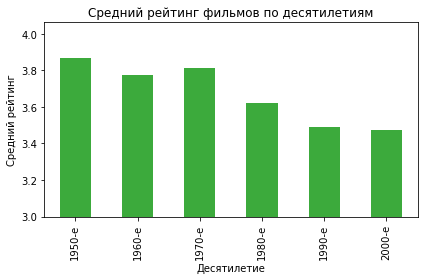

In [9]:
bins = range(1950 // 10 * 10, avg_ratings['year'].max() // 10 * 10 + 11, 10)
labels = [f"{int(i)}-е" for i in bins[:-1]]
# Создаем столбец 'decade'
avg_ratings['decade'] = pd.cut(avg_ratings['year'], bins=bins, labels=labels, right=False)

# Группируем данные по десятилетиям и считаем средний рейтинг
decade_avg = avg_ratings.groupby('decade', as_index=False)['rating'].mean()

decade_avg.plot(kind='bar', x='decade', y='rating',color='#3caa3c', legend=False) 
# Окрашиваем столбцы в цвет влюбленной жабы - #3caa3c, чтобы было веселее.
plt.title('Средний рейтинг фильмов по десятилетиям')
plt.xlabel('Десятилетие')
plt.ylim(3) #Значения рейтинга получились очень близкими и для наглядности пришлось поднять нижнюю шкалу до 3.
plt.ylabel('Средний рейтинг')
plt.xticks() 
plt.tight_layout()
plt.show()


## Вывод:

Рейтинг новых фильмов, действительно ниже, хоть и не сильно.